# The calculator: one object, bound methods

Everything in the other twenty-eight notebooks, reached from a single object. A
`Calculator` is a system together with its pseudopotentials, and each calculation the
package can do is a method on it, so a script names an input file and then names physics.

Nothing here is new physics. The functional entry points the other notebooks use are
unchanged and still work; this is the short way to drive them.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.system.kpoints import KPoints

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_scf")
PSEUDO = Path("../tests/data/pseudo")

calc = Calculator.from_file(QE / "scf.in", pseudo_dir=PSEUDO)
calc

<Calculator: Si2 (2 atoms), nspin=1, ecutwfc=12 Ry, 2 k-points, no SCF yet>

That one line replaced four. `from_file` reads the `pw.x` input, builds the system, and
loads the pseudopotential files the `ATOMIC_SPECIES` card names, resolved against
`pseudo_dir`, which defaults to the input file's own directory. Both halves are still
available as `calc.system` and `calc.pseudos`.

## The ground state is computed once and kept

`get_scf()` runs the SCF and caches it. Called again with the same options it returns the
cache; called with different ones it reruns and replaces it.

In [2]:
result = calc.get_scf(conv_thr=1e-10)
print(result)
print()
print("same options -> the cache:      ", calc.get_scf(conv_thr=1e-10) is result)
print("tighter options -> a new run:   ", calc.get_scf(conv_thr=1e-12) is not result)

<SCFResult: converged in 7 iterations, E = -15.79449557 Ry, accuracy = 6.7e-11 Ry, HOMO = 5.5365 eV>

same options -> the cache:       True
tighter options -> a new run:    True


`calc.scf_result` reads that slot **without** starting anything, which is what makes it
usable in a test; a property that ran an SCF in order to say whether one had been run would
be no use at all. A state that did not converge is refused rather than differentiated.

## Everything else is a method, and each runs the SCF if it has to

Four quantities that between them cover most of the package: a derivative of the energy, a
second derivative, a linear response, and a response differentiated once more.

In [3]:
forces = calc.get_forces()
stress = calc.get_stress()
epsilon = calc.get_dielectric_tensor()
phonons = calc.get_phonons()

print("max force        %10.2e Ry/bohr   (zero by symmetry in the ideal cell)"
      % np.abs(forces.forces).max())
print("pressure         %10.2f kbar" % stress.pressure_kbar)
print("epsilon_inf      %10.4f" % (np.trace(epsilon.epsilon).real / 3))
print("optical mode     %10.2f cm^-1" % phonons.frequencies[-1])

max force          9.07e-19 Ry/bohr   (zero by symmetry in the ideal cell)
pressure             -30.22 kbar
epsilon_inf         21.9164
optical mode         525.76 cm^-1


What the calculator carries for those methods is the whole converged state and not only the
density. The augmentation occupations of an ultrasoft or PAW dataset, the occupation matrix
under a Hubbard `U` and the kinetic energy density under a meta-GGA are all properties of
the *states*, and a response that does not receive them is refused rather than computed
without them.

## Results draw themselves

`BandStructure`, `DensityOfStates`, `ProjectedDOS` and `OpticalSpectrum` each have a
`.plot()` that returns the axes. The zero comes from the SCF's own Fermi level, and is named
after what it actually is: silicon is an insulator, so it has a highest occupied state and
no Fermi level.

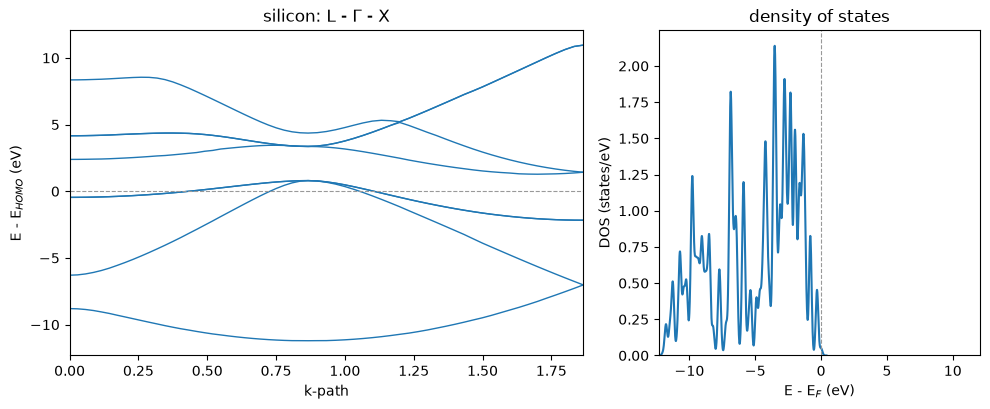

In [4]:
path = KPoints.band_path(
    [[0.5, 0.5, 0.5], [0.0, 0.0, 0.0], [1.0, 0.0, 0.0]],   # L - Gamma - X
    [30, 30, 1], calc.system.cell, crystal=False,
)

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 4.2),
                                  gridspec_kw={"width_ratios": [1.6, 1]})
calc.get_bands(kpoints=path, nbnd=8).plot(ax=left, color="C0")
calc.get_dos(grid=(8, 8, 8), degauss=0.01).plot(ax=right, color="C0")

left.set_title("silicon: L - $\\Gamma$ - X")
right.set_title("density of states")
right.set_xlim(*left.get_ylim())
fig.tight_layout()

Six lines for both panels, and the two calculations behind them share the one converged
density that was already in the cache.

## Nothing mutates

A calculator is never modified in place, because a cached ground state belongs to the
geometry it was converged at: a moved atom under a stale `SCFResult` would answer for the
wrong crystal. `with_positions`, `with_cell` and `with_spin` return a **new** calculator
with an empty cache, and the converged state crosses as a starting guess rather than as an
answer.

In [5]:
positions = np.asarray(calc.system.structure.positions)
moved = calc.with_positions(positions + np.array([0.05, 0.0, 0.0]))
converged = calc.scf_result

print("the parent keeps its state:   ", moved is not calc and calc.scf_result is converged)
print("the derived one has none:     ", moved.scf_result is None)
print("but it starts from the parent:", moved.starting_state is converged)
print()
print("displaced:", moved.get_scf(conv_thr=1e-10).iterations, "iterations from that seed")
print("from scratch:",
      calc.with_positions(positions + np.array([0.05, 0.0, 0.0])).get_scf(
          conv_thr=1e-10, starting_from=None).iterations, "iterations")

the parent keeps its state:    True
the derived one has none:      True
but it starts from the parent: True



displaced: 7 iterations from that seed


from scratch: 7 iterations


On this cell the seed is worth nothing, since two-atom silicon displaced by 0.05 bohr
converges in seven iterations either way, and it is measured rather than asserted for
exactly that reason. Where it pays is where the state is expensive to *find* rather than to
refine: notebook 18 promotes a converged collinear iron into a noncollinear run whose moment
only has to be rotated, and that takes **one** iteration against twenty-five.

---
The tests behind this notebook: `tests/unit/test_calculator.py`.